## ЭТАП 1: ЗАГРУЗКА ДАННЫХ

In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Настройки отображения
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# Загрузка справочников
subjects = pd.read_csv('raw_data/Идентификаторы Субъектов 10.04.2025.csv', sep=';')
mo = pd.read_csv('raw_data/Идентификаторы МО 15.04.2025.csv')

# Загрузка связок
patient_program = pd.read_csv('raw_data/МО и Пациенты 10.04.2025.csv', sep=';')
# Очищаем id пациента от всех видов пробелов
patient_program['id пациента'] = (patient_program['id пациента'].astype(str).str.replace(r'\s+', '', regex=True))  # все пробельные символы.str.replace('\xa0', '', regex=False)  # неразрывный пробел.astype(int))
# Загрузка основных данных (с чанками для больших файлов)
primary_chunks = []
chunk_size = 500000
for chunk in pd.read_csv('raw_data/Первичные данные от 10.04.2025.csv', chunksize=chunk_size, sep=','):
    primary_chunks.append(chunk)
primary = pd.concat(primary_chunks, ignore_index=True)
therapy = pd.read_csv('raw_data/Медикаментозная терапия от 10.04.2025.csv')
kzs = pd.read_csv('raw_data/Клинически значимые события от 15.04.2025.csv')
# Очищаем память от чанков
primary_chunks.clear()
del primary_chunks
print(f"\nЗагружено:")
print(f"  Субъекты: {len(subjects)} строк")
print(f"  МО: {len(mo)} строк")
print(f"  Пациент-программа: {len(patient_program)} строк")
print(f"  Первичные данные: {len(primary):,} строк")
print(f"  Терапия: {len(therapy):,} строк")
print(f"  КЗС: {len(kzs):,} строк")


Загружено:
  Субъекты: 19 строк
  МО: 119 строк
  Пациент-программа: 13943 строк
  Первичные данные: 4,888,853 строк
  Терапия: 23,798 строк
  КЗС: 1,243,036 строк


## ЭТАП 2: ПРОВЕРКА ЦЕЛОСТНОСТИ

In [52]:
# добавляем id субъекта в patient_program по названию
print("Реальные колонки в subjects:", subjects.columns.tolist())
print("Реальные колонки в patient_program:", patient_program.columns.tolist())
patient_program['id пациента'] = patient_program['id пациента'].astype(str).str.replace(' ', '').astype(int)
subject_dict = subjects.set_index('название субъекта')['id субъекта'].to_dict()
# Добавляем id субъекта через map (быстрее и меньше памяти)
patient_program['id субъекта'] = patient_program['название субъекта'].map(subject_dict)
mo_in_patient = patient_program['id МО'].isin(mo['id МО']).mean()
print(f"  % id МО из patient_program, присутствующих в справочнике МО: {mo_in_patient*100:.1f}%")
subj_in_patient = patient_program['id субъекта'].notna().mean()
print(f"  % записей с найденным id субъекта: {subj_in_patient*100:.1f}%")
print(f"Дубликаты в subjects: {subjects.duplicated().sum()}")
print(f"Дубликаты в mo: {mo.duplicated().sum()}")
print(f"Дубликаты в patient_program: {patient_program.duplicated().sum()}")
print(f"Дубликаты в primary (id пациента + время измерения): {primary.duplicated(['id пациента', 'время измерения']).sum():,}")
import gc
gc.collect()

Реальные колонки в subjects: ['id субъекта', 'название субъекта']
Реальные колонки в patient_program: ['название субъекта', 'id МО', 'id программы', 'группа наблюдения', 'id пациента']
  % id МО из patient_program, присутствующих в справочнике МО: 100.0%
  % записей с найденным id субъекта: 100.0%
Дубликаты в subjects: 0
Дубликаты в mo: 0
Дубликаты в patient_program: 0
Дубликаты в primary (id пациента + время измерения): 78,817


15

## ЭТАП 3: ОЧИСТКА ДАННЫХ

In [53]:
# 3.1 Работа с пропусками
print("\n1. Пропуски в первичных данных:")
primary_null = primary.isnull().sum()
primary_null_pct = (primary_null / len(primary)) * 100
null_df = pd.DataFrame({'Пропусков': primary_null, '%': primary_null_pct})
print(null_df[null_df['Пропусков'] > 0])
del primary_null, primary_null_pct, null_df
# 3.2 Форматы данных
# Дата/время
primary['время измерения'] = pd.to_datetime(primary['время измерения'], errors='coerce')
primary['время сохранения на сервере'] = pd.to_datetime(primary['время сохранения на сервере'], errors='coerce')
primary['дата рождения пациента'] = pd.to_datetime(primary['дата рождения пациента'], errors='coerce')
therapy['дата начала программы'] = pd.to_datetime(therapy['дата начала программы'], errors='coerce')
therapy['дата назначения'] = pd.to_datetime(therapy['дата назначения'], errors='coerce')
therapy['дата начала приема'] = pd.to_datetime(therapy['дата начала приема'], errors='coerce')
therapy['дата окончания приема'] = pd.to_datetime(therapy['дата окончания приема'], errors='coerce')
kzs['дата, время формирования КЗС'] = pd.to_datetime(kzs['дата, время формирования КЗС'], errors='coerce')

# Числовые поля
primary['САД'] = pd.to_numeric(primary['САД'], errors='coerce')
primary['ДАД'] = pd.to_numeric(primary['ДАД'], errors='coerce')
primary['ЧП'] = pd.to_numeric(primary['ЧП'], errors='coerce')
primary['рост'] = pd.to_numeric(primary['рост'], errors='coerce')
primary['масса'] = pd.to_numeric(primary['масса'], errors='coerce')

# Расчет возраста на момент измерения
primary['возраст'] = (primary['время измерения'] - primary['дата рождения пациента']).dt.days / 365.25
import gc
gc.collect()


1. Пропуски в первичных данных:
                           Пропусков          %
код пациента                     461   0.009430
рост                         2202449  45.050424
масса                        2202449  45.050424
основное заболевание         2282276  46.683261
сопутствующие заболевание    2945472  60.248733


17

## ЭТАП 4: OUTLIER ANALYSIS

In [54]:
# 4.1 Физиологические границы
print("\n1. Проверка физиологических границ:")

# САД
invalid_sbp = (primary['САД'] < 40) | (primary['САД'] > 250)
print(f"  САД вне нормы (40-250): {invalid_sbp.sum():,} ({invalid_sbp.mean()*100:.5f}%)")

# ДАД
invalid_dbp = (primary['ДАД'] < 30) | (primary['ДАД'] > 150) | (primary['ДАД'] > primary['САД'])
print(f"  ДАД вне нормы (30-150) или >САД: {(invalid_dbp).sum():,} ({invalid_dbp.mean()*100:.5f}%)")

# ЧП
invalid_hr = (primary['ЧП'] < 30) | (primary['ЧП'] > 220)
print(f"  ЧП вне нормы (30-220): {invalid_hr.sum():,} ({invalid_hr.mean()*100:.5f}%)")


# Возраст
invalid_age = (primary['возраст'] < 18) | (primary['возраст'] > 120)
print(f"  Возраст вне нормы (18-120): {invalid_age.sum():,} ({invalid_age.mean()*100:.5f}%)")

# 4.2 Аномалии по времени
print("\n2. Проверка временных аномалий:")

# Будущие измерения
future_meas = primary['время измерения'] > datetime.now()
print(f"  Измерения в будущем: {future_meas.sum():,} ({future_meas.mean()*100:.5f}%)")


# Слишком частые измерения (на одного пациента в день)
primary['date'] = primary['время измерения'].dt.date
patient_daily = primary.groupby(['id пациента', 'date']).size().reset_index(name='n_meas')
freq_meas = patient_daily[patient_daily['n_meas'] > 20]
print(f"  Пациенто-дней с >20 измерений: {len(freq_meas)} ({len(freq_meas)/len(patient_daily)*100:.5f}%)")

primary.drop('date', axis=1, inplace=True) 
del patient_daily
del freq_meas
import gc
gc.collect()


1. Проверка физиологических границ:
  САД вне нормы (40-250): 19 (0.00039%)
  ДАД вне нормы (30-150) или >САД: 173 (0.00354%)
  ЧП вне нормы (30-220): 0 (0.00000%)
  Возраст вне нормы (18-120): 243 (0.00497%)

2. Проверка временных аномалий:
  Измерения в будущем: 0 (0.00000%)
  Пациенто-дней с >20 измерений: 2914 (0.25137%)


20

## ЭТАП 5: АНАЛИЗ ПО ГРУППАМ

In [55]:
unique_patients = patient_program[['id пациента', 'группа наблюдения']].drop_duplicates('id пациента')
primary = primary.merge(
    unique_patients,
    on='id пациента',
    how='left'
)
del unique_patients
print("\n1. Распределение групп:")
group_dist = primary['группа наблюдения'].value_counts(dropna=False)
print(group_dist)
print(f"\nВсего пациентов в группах: {group_dist.sum():,}")
print("\n2. Статистика измерений по группам:")
group_stats_nunique = primary.groupby('группа наблюдения')['id пациента'].nunique()
group_stats_sad = primary.groupby('группа наблюдения')['САД'].agg(['mean', 'std', 'count']).round(1)
group_stats_dad = primary.groupby('группа наблюдения')['ДАД'].agg(['mean', 'std']).round(1)
group_stats_chp = primary.groupby('группа наблюдения')['ЧП'].agg(['mean', 'std']).round(1)
group_stats = pd.concat([
    group_stats_nunique.rename('count_patients'),
    group_stats_sad,
    group_stats_dad,
    group_stats_chp
], axis=1)
del group_stats_nunique, group_stats_sad, group_stats_dad, group_stats_chp
print(group_stats)


1. Распределение групп:
группа наблюдения
undefined     3788494
experience     878754
control_1      221605
Name: count, dtype: int64

Всего пациентов в группах: 4,888,853

2. Статистика измерений по группам:
                   count_patients   mean   std    count  mean   std  mean  \
группа наблюдения                                                           
control_1                     369  128.7  17.1   221605  81.3  11.9  71.5   
experience                   1305  129.6  17.8   878754  81.3  11.6  71.3   
undefined                    9263  126.9  18.2  3788494  79.5  11.8  71.1   

                    std  
группа наблюдения        
control_1          11.3  
experience         11.5  
undefined          11.9  


## ЭТАП 6: ВИЗУАЛИЗАЦИЯ

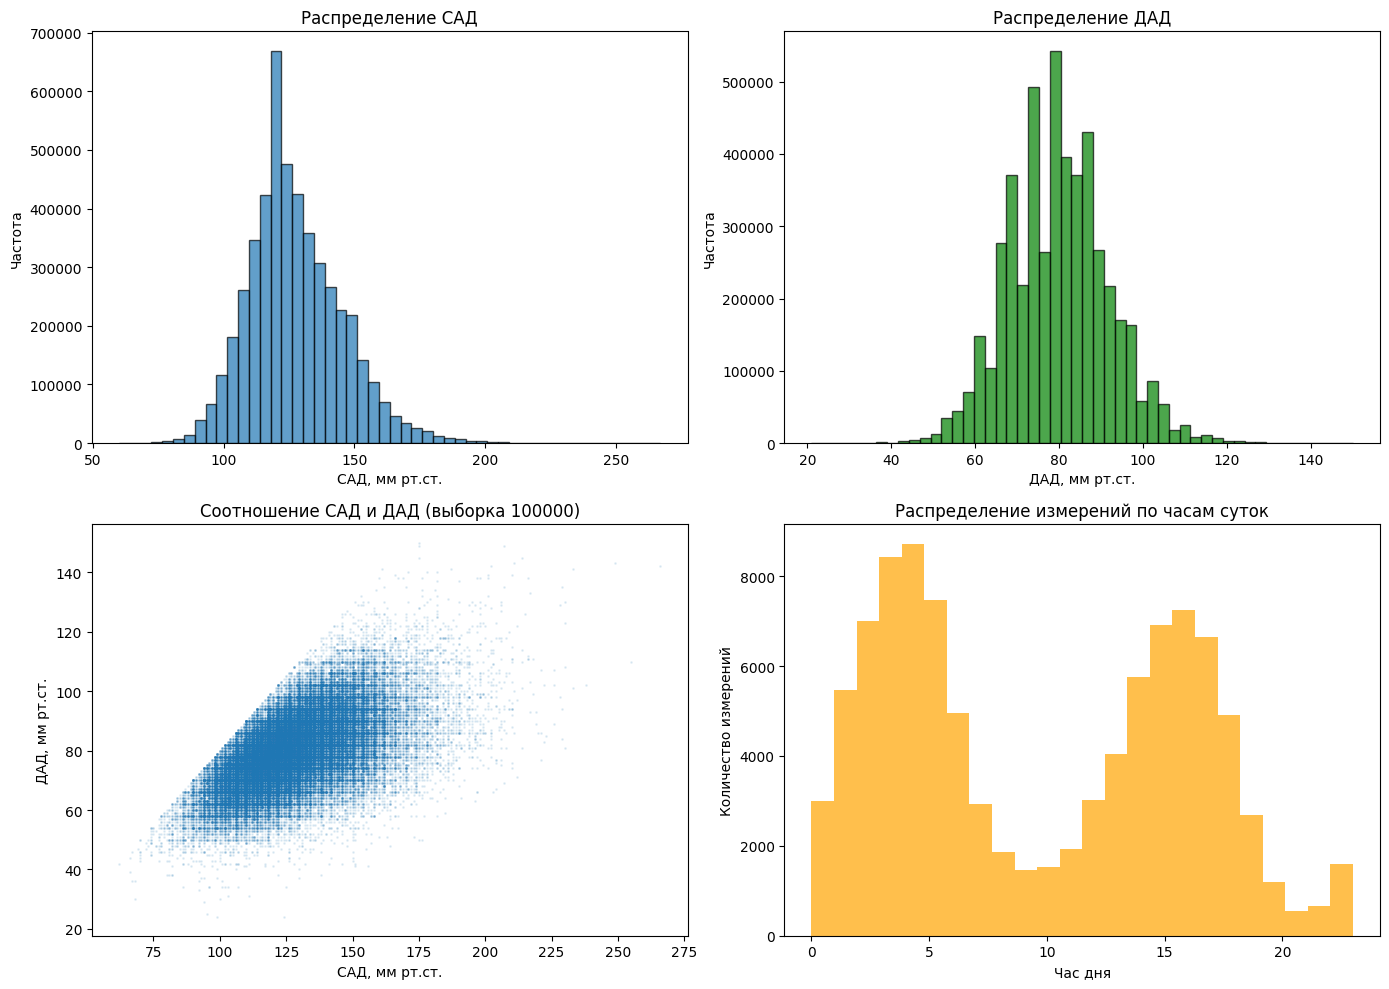

In [56]:
# Создаем фиксированные выборки один раз
sample_size = min(100000, len(primary))
sample_indices = np.random.RandomState(42).choice(len(primary), sample_size, replace=False)
primary_sample = primary.iloc[sample_indices]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Распределение САД
axes[0, 0].hist(primary['САД'].dropna(), bins=50, alpha=0.7, edgecolor='black')
axes[0, 0].set_title('Распределение САД')
axes[0, 0].set_xlabel('САД, мм рт.ст.')
axes[0, 0].set_ylabel('Частота')

# 2. Распределение ДАД
axes[0, 1].hist(primary['ДАД'].dropna(), bins=50, alpha=0.7, edgecolor='black', color='green')
axes[0, 1].set_title('Распределение ДАД')
axes[0, 1].set_xlabel('ДАД, мм рт.ст.')
axes[0, 1].set_ylabel('Частота')

# 3. Соотношение САД и ДАД (используем фиксированную выборку)
axes[1, 0].scatter(primary_sample['САД'], primary_sample['ДАД'], alpha=0.1, s=1)
axes[1, 0].set_title(f'Соотношение САД и ДАД (выборка {sample_size})')
axes[1, 0].set_xlabel('САД, мм рт.ст.')
axes[1, 0].set_ylabel('ДАД, мм рт.ст.')

# 4. Измерения по времени (используем ту же выборку)
axes[1, 1].hist(primary_sample['время измерения'].dt.hour.dropna(), bins=24, alpha=0.7, color='orange')
axes[1, 1].set_title('Распределение измерений по часам суток')
axes[1, 1].set_xlabel('Час дня')
axes[1, 1].set_ylabel('Количество измерений')

plt.tight_layout()
plt.savefig('data/photo/eda_basic_plots.png', dpi=100)

In [57]:
# Очистка памяти
plt.close(fig)
del primary_sample
del sample_indices

## ЭТАП 7: АНАЛИЗ КЗС И ТЕРАПИИ

In [58]:
# КЗС анализ
print("\n1. Топ-10 КЗС:")
kzs_counts = kzs['код КЗС'].value_counts().head(10)
print(kzs_counts)
del kzs_counts

kzs_per_patient = kzs.groupby('id пациента').size()
print(f"\n2. Статистика КЗС на пациента:")
print(f"  Среднее: {kzs_per_patient.mean():.1f}")
print(f"  Медиана: {kzs_per_patient.median():.1f}")
print(f"  Макс: {kzs_per_patient.max():,}")
print(f"  % пациентов с КЗС: {(len(kzs_per_patient) / patient_program['id пациента'].nunique() * 100):.1f}%")
del kzs_per_patient
# Терапия анализ
print(f"\n3. Всего записей терапии: {len(therapy):,}")
if 'МНН' in therapy.columns:
    print("\n4. Топ-10 назначаемых МНН:")
    mnn_counts = therapy['МНН'].value_counts().head(10)
    print(mnn_counts)
    del mnn_counts
import gc
gc.collect()


1. Топ-10 КЗС:
код КЗС
33921    449841
33923    192832
33911    156247
33430    107624
33922     85990
33913     40120
33431     34872
33901     26824
33924     20063
77710     19001
Name: count, dtype: int64

2. Статистика КЗС на пациента:
  Среднее: 115.5
  Медиана: 81.0
  Макс: 881
  % пациентов с КЗС: 91.7%

3. Всего записей терапии: 23,798

4. Топ-10 назначаемых МНН:
МНН
бисопролол      2789
индапамид       2621
амлодипин       2454
лозартан        2308
периндоприл     1888
эналаприл       1193
аторвастатин     946
лизиноприл       762
моксонидин       706
валсартан        697
Name: count, dtype: int64


25

## ЭТАП 8: СОХРАНЕНИЕ И СТАТИСТИКА

In [59]:
clean_primary = primary[~invalid_sbp & ~invalid_dbp & ~invalid_hr & ~invalid_age & ~future_meas].copy()
print(f"Удалено выбросов: {len(primary) - len(clean_primary)} ({100 - len(clean_primary)/len(primary)*100:.1f}%)")
del invalid_sbp  
del invalid_dbp
clean_primary.to_csv('data/primary_clean.csv', index=False)
patient_program.to_csv('data/patient_program.csv', index=False)
kzs.to_csv('data/kzs.csv', index=False)
therapy.to_csv('data/therapy.csv', index=False)

print(f"""
Статистика:
- Пациентов: {patient_program['id пациента'].nunique():,}
- Измерений: {len(clean_primary):,}
- КЗС: {len(kzs):,}
- Записей терапии: {len(therapy):,}
- САД: {clean_primary['САД'].mean():.4f} мм рт.ст.
- ДАД: {clean_primary['ДАД'].mean():.4f} мм рт.ст.
- Возраст: {clean_primary['возраст'].mean():.4f} лет
""")
del future_meas
del invalid_age
del invalid_hr
import gc
gc.collect()

Удалено выбросов: 435 (0.0%)

Статистика:
- Пациентов: 11,739
- Измерений: 4,888,418
- КЗС: 1,243,036
- Записей терапии: 23,798
- САД: 127.4812 мм рт.ст.
- ДАД: 79.8754 мм рт.ст.
- Возраст: 63.7037 лет



0

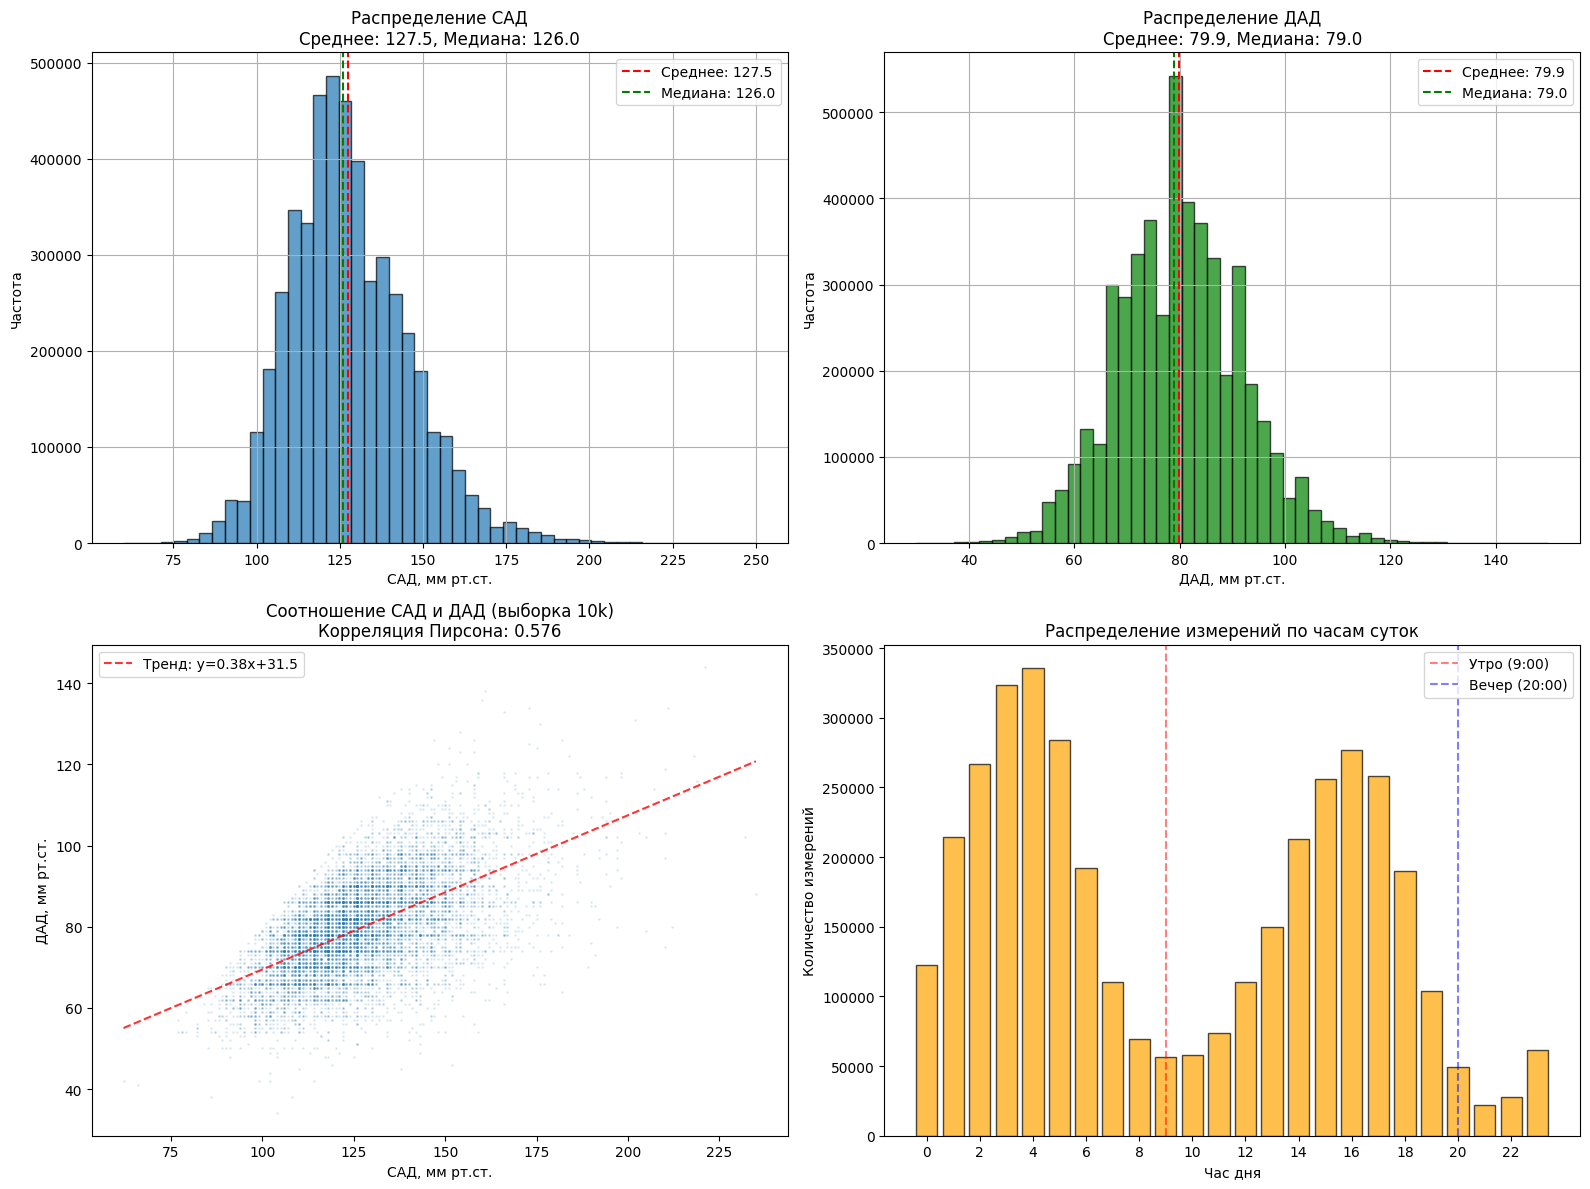


Анализ графиков:

1. Распределение САД:
   - Среднее: 127.5 мм рт.ст.
   - Медиана: 126.0 мм рт.ст.
   - Стандартное отклонение: 18.1
   - 25-й перцентиль: 115.0
   - 75-й перцентиль: 138.0

2. Распределение ДАД:
   - Среднее: 79.9 мм рт.ст.
   - Медиана: 79.0 мм рт.ст.
   - Стандартное отклонение: 11.8
   - 25-й перцентиль: 72.0
   - 75-й перцентиль: 87.0

3. Корреляция САД и ДАД: 0.576
   - Умеренная положительная корреляция

4. Анализ времени измерений:
   - Утренние часы (6-10): 486,264 измерений (12.7%)
   - Вечерние часы (18-22): 393,168 измерений (10.3%)
   - Ночные часы (22-6): 1,636,275 измерений (42.8%)
   - Дневные часы (10-18): 1,310,381 измерений (34.2%)


In [60]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from datetime import datetime

# Загружаем очищенные данные с явным указанием типов
clean_primary = pd.read_csv('data/primary_clean.csv', 
                           parse_dates=['время измерения', 'время сохранения на сервере', 'дата рождения пациента'])

# Создаем улучшенные графики
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Распределение САД с KDE
ax1 = axes[0, 0]
clean_primary['САД'].dropna().hist(bins=50, alpha=0.7, edgecolor='black', ax=ax1)
ax1.set_title('Распределение САД\nСреднее: {:.1f}, Медиана: {:.1f}'.format(
    clean_primary['САД'].mean(), clean_primary['САД'].median()))
ax1.set_xlabel('САД, мм рт.ст.')
ax1.set_ylabel('Частота')
ax1.axvline(clean_primary['САД'].mean(), color='red', linestyle='--', 
            label=f'Среднее: {clean_primary["САД"].mean():.1f}')
ax1.axvline(clean_primary['САД'].median(), color='green', linestyle='--', 
            label=f'Медиана: {clean_primary["САД"].median():.1f}')
ax1.legend()

# 2. Распределение ДАД с KDE
ax2 = axes[0, 1]
clean_primary['ДАД'].dropna().hist(bins=50, alpha=0.7, edgecolor='black', color='green', ax=ax2)
ax2.set_title('Распределение ДАД\nСреднее: {:.1f}, Медиана: {:.1f}'.format(
    clean_primary['ДАД'].mean(), clean_primary['ДАД'].median()))
ax2.set_xlabel('ДАД, мм рт.ст.')
ax2.set_ylabel('Частота')
ax2.axvline(clean_primary['ДАД'].mean(), color='red', linestyle='--', 
            label=f'Среднее: {clean_primary["ДАД"].mean():.1f}')
ax2.axvline(clean_primary['ДАД'].median(), color='green', linestyle='--', 
            label=f'Медиана: {clean_primary["ДАД"].median():.1f}')
ax2.legend()

# 3. Соотношение САД и ДАД с корреляцией
ax3 = axes[1, 0]
sample = clean_primary.sample(min(10000, len(clean_primary)))
ax3.scatter(sample['САД'], sample['ДАД'], alpha=0.1, s=1)
corr = sample['САД'].corr(sample['ДАД'])
ax3.set_title(f'Соотношение САД и ДАД (выборка 10k)\nКорреляция Пирсона: {corr:.3f}')
ax3.set_xlabel('САД, мм рт.ст.')
ax3.set_ylabel('ДАД, мм рт.ст.')

# Добавляем линию регрессии
z = np.polyfit(sample['САД'].dropna(), sample['ДАД'].dropna(), 1)
p = np.poly1d(z)
ax3.plot(sample['САД'].sort_values(), p(sample['САД'].sort_values()), 
         "r--", alpha=0.8, label=f'Тренд: y={z[0]:.2f}x+{z[1]:.1f}')
ax3.legend()

# 4. Распределение по часам (с проверкой типа данных)
ax4 = axes[1, 1]

# Явно преобразуем в datetime если ещё не
if not pd.api.types.is_datetime64_any_dtype(clean_primary['время измерения']):
    clean_primary['время измерения'] = pd.to_datetime(clean_primary['время измерения'], errors='coerce')

# Теперь извлекаем часы
hours = clean_primary['время измерения'].dt.hour.dropna()
hour_counts = hours.value_counts().sort_index()

ax4.bar(hour_counts.index, hour_counts.values, alpha=0.7, color='orange', edgecolor='black')
ax4.set_title('Распределение измерений по часам суток')
ax4.set_xlabel('Час дня')
ax4.set_ylabel('Количество измерений')
ax4.set_xticks(range(0, 24, 2))

# Добавляем вертикальные линии для утренних и вечерних пиков
ax4.axvline(x=9, color='red', linestyle='--', alpha=0.5, label='Утро (9:00)')
ax4.axvline(x=20, color='blue', linestyle='--', alpha=0.5, label='Вечер (20:00)')
ax4.legend()

plt.tight_layout()
plt.savefig('data/photo/eda_detailed_plots.png', dpi=150)
plt.show()

print("\nАнализ графиков:")
print("="*50)

print("\n1. Распределение САД:")
print(f"   - Среднее: {clean_primary['САД'].mean():.1f} мм рт.ст.")
print(f"   - Медиана: {clean_primary['САД'].median():.1f} мм рт.ст.")
print(f"   - Стандартное отклонение: {clean_primary['САД'].std():.1f}")
print(f"   - 25-й перцентиль: {clean_primary['САД'].quantile(0.25):.1f}")
print(f"   - 75-й перцентиль: {clean_primary['САД'].quantile(0.75):.1f}")

print("\n2. Распределение ДАД:")
print(f"   - Среднее: {clean_primary['ДАД'].mean():.1f} мм рт.ст.")
print(f"   - Медиана: {clean_primary['ДАД'].median():.1f} мм рт.ст.")
print(f"   - Стандартное отклонение: {clean_primary['ДАД'].std():.1f}")
print(f"   - 25-й перцентиль: {clean_primary['ДАД'].quantile(0.25):.1f}")
print(f"   - 75-й перцентиль: {clean_primary['ДАД'].quantile(0.75):.1f}")

print(f"\n3. Корреляция САД и ДАД: {corr:.3f}")
if corr > 0.7:
    print("   - Сильная положительная корреляция (ожидаемо для АД)")
elif corr > 0.5:
    print("   - Умеренная положительная корреляция")
else:
    print("   - Слабая корреляция (возможно, требует проверки)")

# Анализ времени измерений
peak_morning = hour_counts[6:10].sum() if 6 in hour_counts.index else 0
peak_evening = hour_counts[18:22].sum() if 18 in hour_counts.index else 0
night_meas = sum(hour_counts[h] for h in range(0, 6) if h in hour_counts.index) + \
            sum(hour_counts[h] for h in range(22, 24) if h in hour_counts.index)

total_meas = len(hours)
print("\n4. Анализ времени измерений:")
print(f"   - Утренние часы (6-10): {peak_morning:,} измерений ({peak_morning/total_meas*100:.1f}%)")
print(f"   - Вечерние часы (18-22): {peak_evening:,} измерений ({peak_evening/total_meas*100:.1f}%)")
print(f"   - Ночные часы (22-6): {night_meas:,} измерений ({night_meas/total_meas*100:.1f}%)")
print(f"   - Дневные часы (10-18): {total_meas - peak_morning - peak_evening - night_meas:,} измерений ({(total_meas - peak_morning - peak_evening - night_meas)/total_meas*100:.1f}%)")

In [61]:
plt.close(fig)  # Важно! Закрываем фигуру
del sample
del hour_counts
del hours
del axes
import gc
gc.collect()

37970

## ЭТАП 10: АНАЛИЗ ПО ГРУППАМ НАБЛЮДЕНИЯ


Статистика измерений по группам:
    Группа  Пациентов Ср. измерений Мед. измерений  Мин  Макс Сумма измерений
 control_1        369         600.5          467.0    1  4683         221,600
experience       1305         673.4          554.0    1  6204         878,726
 undefined       9261         409.0          255.0    1  5635       3,788,092


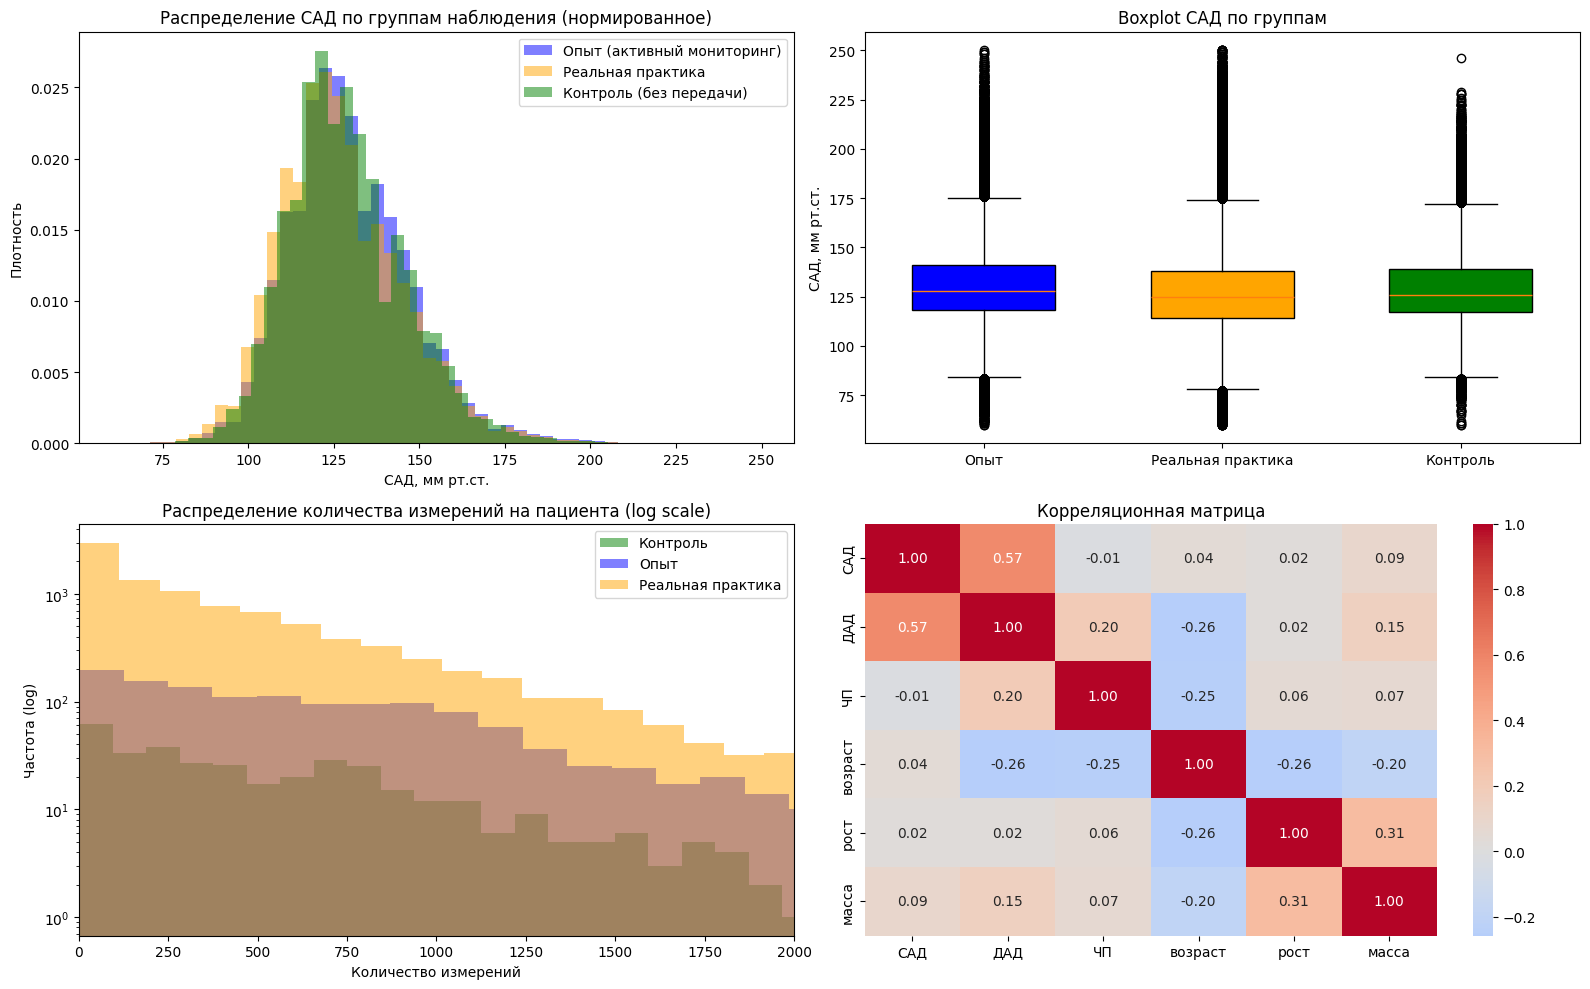

5905

In [62]:
# Убедимся, что у нас есть группа наблюдения
if 'группа наблюдения' not in clean_primary.columns:
    patient_program = pd.read_csv('data/patient_program.csv')
    clean_primary = clean_primary.merge(
        patient_program[['id пациента', 'группа наблюдения']].drop_duplicates('id пациента'),
        on='id пациента',
        how='left'
    )
    del patient_program  # удаляем после использования

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
groups = clean_primary['группа наблюдения'].dropna().unique()
colors = {'experience': 'blue', 'control_1': 'green', 'undefined': 'orange'}

for i, group_name in enumerate(groups):
    group_data = clean_primary[clean_primary['группа наблюдения'] == group_name]
    
    if group_name == 'experience':
        label = 'Опыт (активный мониторинг)'
    elif group_name == 'control_1':
        label = 'Контроль (без передачи)'
    else:
        label = 'Реальная практика'
    
    # Распределение САД по группам
    axes[0, 0].hist(group_data['САД'].dropna(), bins=50, alpha=0.5, 
                    color=colors.get(group_name, 'gray'), label=label, density=True)
    
    # Boxplot САД (без присваивания)
    axes[0, 1].boxplot(group_data['САД'].dropna(), positions=[i], widths=0.6,
                       patch_artist=True, 
                       boxprops=dict(facecolor=colors.get(group_name, 'gray')))

axes[0, 0].set_title('Распределение САД по группам наблюдения (нормированное)')
axes[0, 0].set_xlabel('САД, мм рт.ст.')
axes[0, 0].set_ylabel('Плотность')
axes[0, 0].legend()

axes[0, 1].set_title('Boxplot САД по группам')
axes[0, 1].set_xticks(range(len(groups)))
axes[0, 1].set_xticklabels(['Опыт' if g=='experience' else 'Контроль' if g=='control_1' else 'Реальная практика' for g in groups])
axes[0, 1].set_ylabel('САД, мм рт.ст.')

# Количество измерений на пациента по группам
meas_per_patient = clean_primary.groupby(['группа наблюдения', 'id пациента']).size().reset_index(name='n_meas')
for group_name, group_data in meas_per_patient.groupby('группа наблюдения'):
    axes[1, 0].hist(group_data['n_meas'], bins=50, alpha=0.5, 
                    color=colors.get(group_name, 'gray'), 
                    label=('Опыт' if group_name=='experience' else 'Контроль' if group_name=='control_1' else 'Реальная практика'), 
                    log=True)

axes[1, 0].set_title('Распределение количества измерений на пациента (log scale)')
axes[1, 0].set_xlabel('Количество измерений')
axes[1, 0].set_ylabel('Частота (log)')
axes[1, 0].legend()
axes[1, 0].set_xlim([0, 2000])

# Статистика по группам
group_stats = []
for group_name, group_data in meas_per_patient.groupby('группа наблюдения'):
    group_stats.append({
        'Группа': group_name,
        'Пациентов': len(group_data),
        'Ср. измерений': f"{group_data['n_meas'].mean():.1f}",
        'Мед. измерений': f"{group_data['n_meas'].median():.1f}",
        'Мин': group_data['n_meas'].min(),
        'Макс': group_data['n_meas'].max(),
        'Сумма измерений': f"{group_data['n_meas'].sum():,}"
    })

group_stats_df = pd.DataFrame(group_stats)
print("\nСтатистика измерений по группам:")
print(group_stats_df.to_string(index=False))

# Очищаем временные данные статистики
del meas_per_patient
del group_stats
del group_stats_df

# Тепловая карта корреляций
numeric_cols = ['САД', 'ДАД', 'ЧП', 'возраст', 'рост', 'масса']
available_numeric = [col for col in numeric_cols if col in clean_primary.columns]
corr_matrix = clean_primary[available_numeric].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=axes[1, 1])
axes[1, 1].set_title('Корреляционная матрица')

del corr_matrix  # очищаем матрицу корреляции
plt.tight_layout()
plt.savefig('data/photo/eda_group_analysis.png', dpi=150)
plt.show()
plt.close(fig)
del axes
import gc
gc.collect()

## ЭТАП 11: АНАЛИЗ КАЧЕСТВА ДАННЫХ

In [63]:
# Пропуски по группам
print("\n1. Пропуски в критических полях по группам:")
missing_cols = ['рост', 'масса', 'основное заболевание', 'сопутствующие заболевание']
available_missing = [col for col in missing_cols if col in clean_primary.columns]

if available_missing:
    missing_by_group = clean_primary.groupby('группа наблюдения')[available_missing].agg(
        lambda x: x.isna().mean() * 100
    ).round(1)
    print(missing_by_group)
    del missing_by_group  # удаляем после вывода
else:
    print("   Поля с пропусками не найдены в данных")

# Регулярность измерений
print("\n2. Регулярность измерений:")
clean_primary['год_месяц'] = clean_primary['время измерения'].dt.to_period('M')
meas_by_month = clean_primary.groupby(['id пациента', 'год_месяц']).size().reset_index(name='n_meas_month')
patients_with_regular_meas = meas_by_month.groupby('id пациента').size()

print(f"   - Пациенты с измерениями в 1 месяц: {(patients_with_regular_meas == 1).sum()}")
print(f"   - Пациенты с измерениями в 2-6 месяцев: {((patients_with_regular_meas >= 2) & (patients_with_regular_meas <= 6)).sum()}")
print(f"   - Пациенты с измерениями в 7+ месяцев: {(patients_with_regular_meas >= 7).sum()}")

# Очищаем временные объекты
del meas_by_month
del patients_with_regular_meas
clean_primary = clean_primary.drop('год_месяц', axis=1)

# Временная задержка
if 'время сохранения на сервере' in clean_primary.columns:
    clean_primary['задержка_сек'] = (pd.to_datetime(clean_primary['время сохранения на сервере']) - 
                                     pd.to_datetime(clean_primary['время измерения'])).dt.total_seconds()
    delay_stats = clean_primary['задержка_сек'].describe(percentiles=[0.5, 0.9, 0.95, 0.99])
    print(f"\n3. Задержка передачи данных (секунд):")
    print(f"   - Медиана: {delay_stats['50%']:.0f} сек")
    print(f"   - 90-й перцентиль: {delay_stats['90%']:.0f} сек")
    print(f"   - 95-й перцентиль: {delay_stats['95%']:.0f} сек")
    print(f"   - 99-й перцентиль: {delay_stats['99%']:.0f} сек")
    
    # Выявляем аномально большие задержки
    large_delay = clean_primary[clean_primary['задержка_сек'] > 86400]  # > 1 дня
    print(f"\n   - Измерений с задержкой > 1 дня: {len(large_delay)} ({len(large_delay)/len(clean_primary)*100:.3f}%)")
    
    # Очищаем временные объекты
    clean_primary = clean_primary.drop('задержка_сек', axis=1)
    del large_delay
else:
    print("\n3. Информация о задержке передачи недоступна")

import gc
gc.collect()


1. Пропуски в критических полях по группам:
                   рост  масса  основное заболевание  \
группа наблюдения                                      
control_1          89.8   89.8                  96.9   
experience         88.1   88.1                  94.0   
undefined          32.4   32.4                  32.8   

                   сопутствующие заболевание  
группа наблюдения                             
control_1                               96.9  
experience                              94.1  
undefined                               50.3  

2. Регулярность измерений:
   - Пациенты с измерениями в 1 месяц: 869
   - Пациенты с измерениями в 2-6 месяцев: 5825
   - Пациенты с измерениями в 7+ месяцев: 3309

3. Задержка передачи данных (секунд):
   - Медиана: 3 сек
   - 90-й перцентиль: 5 сек
   - 95-й перцентиль: 22 сек
   - 99-й перцентиль: 48264 сек

   - Измерений с задержкой > 1 дня: 23528 (0.481%)


38

## ЭТАП 12: ОЧИСТКА ДУБЛИКАТОВ И АНАЛИЗ НОЧНЫХ ИЗМЕРЕНИЙ

Загружено измерений: 4,888,418

Проверка типов данных:
время измерения                        object
время сохранения на сервере    datetime64[ns]
dtype: object
Удалено строк с некорректными датами: 1062330
1. УДАЛЕНИЕ ДУБЛИКАТОВ
Найдено дубликатов: 116,839

Примеры дубликатов:
         id пациента     время измерения  САД  ДАД  ЧП
1812078        10768 2024-05-11 01:26:46  102   59  66
1812079        10768 2024-05-11 01:26:46  104   62  67
1904679        10768 2024-05-17 01:11:42  104   61  65
4052141        10768 2024-05-17 01:11:42  114   58  61
2397751        10768 2024-06-24 00:53:53  128   65  78
2397752        10768 2024-06-24 00:53:53  126   68  76
2539986        10768 2024-07-07 01:19:57  135   64  69
2539987        10768 2024-07-07 01:19:57  122   62  68
2539989        10768 2024-07-07 01:19:59  120   62  61
4179440        10768 2024-07-07 01:19:59  106   62  64

После удаления дубликатов: 3,763,804 измерений
Удалено: 58,419 полных дубликатов
2. АНАЛИЗ НОЧНЫХ ИЗМЕРЕНИЙ

Информ

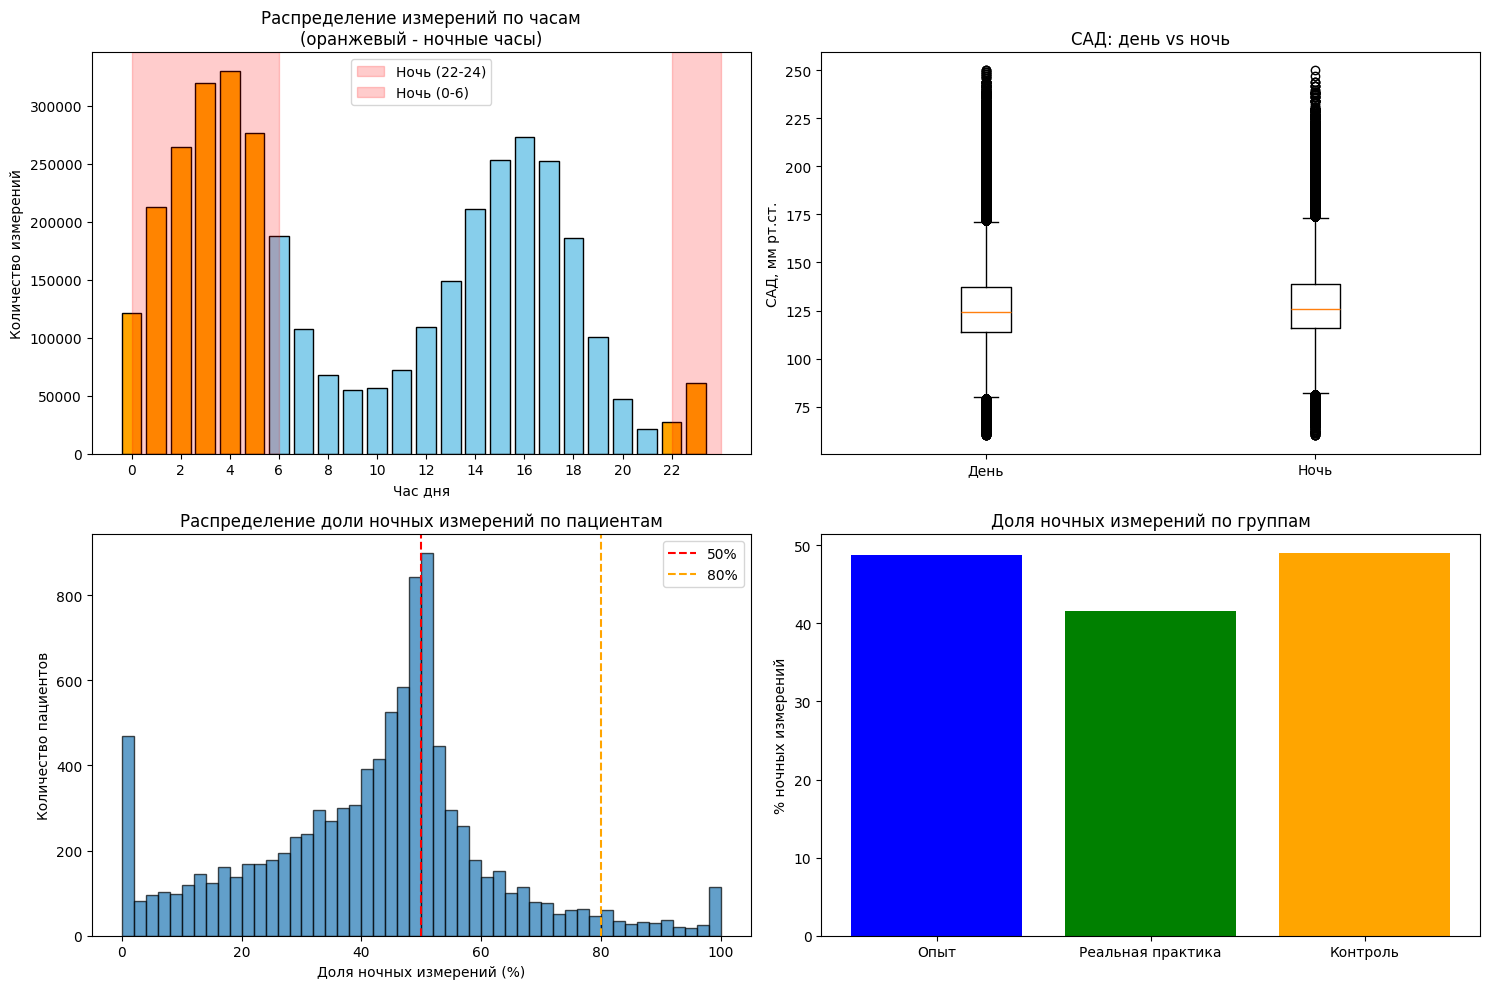

3. КОРРЕКЦИЯ ЧАСОВЫХ ПОЯСОВ
Информация о часовых поясах доступна. Проверяем необходимость коррекции...

Распределение по часовым поясам:
часовой пояс
3    1671426
4      70115
5    1151482
7     865930
9       4851
Name: count, dtype: int64

Ночные измерения до коррекции: 42.9%
Ночные измерения после коррекции: 14.0%
Коррекция часовых поясов уменьшила долю ночных измерений
Анализ завершен, память очищена


In [64]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
import gc

# Загружаем данные
clean_primary = pd.read_csv('data/primary_clean.csv', parse_dates=['время измерения', 'время сохранения на сервере'])
print(f"Загружено измерений: {len(clean_primary):,}")

# Проверка типов данных
print("\nПроверка типов данных:")
print(clean_primary[['время измерения', 'время сохранения на сервере']].dtypes)

# Принудительное преобразование в datetime
clean_primary['время измерения'] = pd.to_datetime(clean_primary['время измерения'], errors='coerce')
clean_primary['время сохранения на сервере'] = pd.to_datetime(clean_primary['время сохранения на сервере'], errors='coerce')

# Удаляем строки с некорректными датами
initial_len = len(clean_primary)
clean_primary = clean_primary.dropna(subset=['время измерения'])
print(f"Удалено строк с некорректными датами: {initial_len - len(clean_primary)}")

# 1. УДАЛЕНИЕ ДУБЛИКАТОВ
print("1. УДАЛЕНИЕ ДУБЛИКАТОВ")
duplicates_mask = clean_primary.duplicated(subset=['id пациента', 'время измерения'], keep=False)
duplicates = clean_primary[duplicates_mask].sort_values(['id пациента', 'время измерения'])
print(f"Найдено дубликатов: {len(duplicates):,}")

if len(duplicates) > 0:
    print("\nПримеры дубликатов:")
    print(duplicates[['id пациента', 'время измерения', 'САД', 'ДАД', 'ЧП']].head(10))
    
    clean_primary = clean_primary.drop_duplicates(subset=['id пациента', 'время измерения'], keep='first')
    print(f"\nПосле удаления дубликатов: {len(clean_primary):,} измерений")
    print(f"Удалено: {len(duplicates)//2:,} полных дубликатов")
    
    del duplicates
    gc.collect()

# 2. АНАЛИЗ НОЧНЫХ ИЗМЕРЕНИЙ
print("2. АНАЛИЗ НОЧНЫХ ИЗМЕРЕНИЙ")
clean_primary['час_измерения'] = clean_primary['время измерения'].dt.hour
clean_primary['дата_измерения'] = clean_primary['время измерения'].dt.date

if 'часовой пояс пациента' in clean_primary.columns:
    print("\nИнформация о часовых поясах доступна")
    clean_primary['часовой пояс'] = pd.to_numeric(clean_primary['часовой пояс пациента'], errors='coerce')
    print("\nРаспределение по часовым поясам (все измерения):")
    print(clean_primary['часовой пояс'].value_counts().sort_index())
else:
    print("\nИнформация о часовом поясе отсутствует")
    clean_primary['часовой пояс'] = 0

night_mask = (clean_primary['час_измерения'] >= 22) | (clean_primary['час_измерения'] < 6)

print(f"\nДневные измерения: {len(clean_primary[~night_mask]):,} ({len(clean_primary[~night_mask])/len(clean_primary)*100:.1f}%)")
print(f"Ночные измерения: {len(clean_primary[night_mask]):,} ({len(clean_primary[night_mask])/len(clean_primary)*100:.1f}%)")

if len(clean_primary[night_mask]) > 0:
    timezone_night = clean_primary[night_mask].groupby('часовой пояс').size()
    print("\nАнализ по часовым поясам (ночные измерения):")
    print(timezone_night)
    
    print("\nПроцент ночных измерений по часовым поясам:")
    for tz in clean_primary['часовой пояс'].unique():
        tz_data = clean_primary[clean_primary['часовой пояс'] == tz]
        if len(tz_data) > 0:
            tz_night_pct = ((tz_data['час_измерения'] >= 22) | (tz_data['час_измерения'] < 6)).mean() * 100
            print(f"  Часовой пояс {tz}: {tz_night_pct:.1f}% ночных измерений")
    
    night_per_patient = clean_primary[night_mask].groupby('id пациента').size().reset_index(name='ночных_измерений')
    total_per_patient = clean_primary.groupby('id пациента').size().reset_index(name='всего_измерений')
    night_per_patient = night_per_patient.merge(total_per_patient, on='id пациента', how='right').fillna(0)
    night_per_patient['доля_ночных'] = (night_per_patient['ночных_измерений'] / night_per_patient['всего_измерений'] * 100).round(1)
    
    print("\nСтатистика ночных измерений на пациента:")
    print(f"  Средняя доля ночных: {night_per_patient['доля_ночных'].mean():.1f}%")
    print(f"  Медиана доли ночных: {night_per_patient['доля_ночных'].median():.1f}%")
    print(f"  Пациентов с >50% ночных: {(night_per_patient['доля_ночных'] > 50).sum()}")
    
    high_night_patients = night_per_patient[night_per_patient['доля_ночных'] > 80]
    print(f"\nПациентов с >80% ночных измерений: {len(high_night_patients)}")
    if len(high_night_patients) > 0:
        print("Примеры пациентов с аномально высоким процентом ночных измерений:")
        print(high_night_patients.head(10))
    
    del night_per_patient, total_per_patient, high_night_patients
    gc.collect()

if 'время сохранения на сервере' in clean_primary.columns:
    clean_primary['задержка_сек'] = (clean_primary['время сохранения на сервере'] - clean_primary['время измерения']).dt.total_seconds()
    
    night_delay = clean_primary.loc[night_mask, 'задержка_сек'].median()
    day_delay = clean_primary.loc[~night_mask, 'задержка_сек'].median()
    
    print(f"\nМедиана задержки:")
    print(f"  Дневные измерения: {day_delay:.0f} сек")
    print(f"  Ночные измерения: {night_delay:.0f} сек")
    
    if night_delay > day_delay * 2:
        print("Ночные измерения имеют значительно большую задержку")
else:
    print("\nИнформация о задержке передачи недоступна")

# Визуализация
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

hour_counts = clean_primary['час_измерения'].value_counts().sort_index()
colors = ['orange' if (h < 6 or h >= 22) else 'skyblue' for h in hour_counts.index]
axes[0, 0].bar(hour_counts.index, hour_counts.values, color=colors, edgecolor='black')
axes[0, 0].set_title('Распределение измерений по часам\n(оранжевый - ночные часы)')
axes[0, 0].set_xlabel('Час дня')
axes[0, 0].set_ylabel('Количество измерений')
axes[0, 0].set_xticks(range(0, 24, 2))
axes[0, 0].axvspan(22, 24, alpha=0.2, color='red', label='Ночь (22-24)')
axes[0, 0].axvspan(0, 6, alpha=0.2, color='red', label='Ночь (0-6)')
axes[0, 0].legend()

day_sad = clean_primary.loc[~night_mask, 'САД'].dropna()
night_sad = clean_primary.loc[night_mask, 'САД'].dropna()
axes[0, 1].boxplot([day_sad, night_sad], labels=['День', 'Ночь'])
axes[0, 1].set_title('САД: день vs ночь')
axes[0, 1].set_ylabel('САД, мм рт.ст.')

night_by_patient = clean_primary[night_mask].groupby('id пациента').size()
total_by_patient = clean_primary.groupby('id пациента').size()
night_share = (night_by_patient / total_by_patient * 100).fillna(0)
axes[1, 0].hist(night_share, bins=50, edgecolor='black', alpha=0.7)
axes[1, 0].set_title('Распределение доли ночных измерений по пациентам')
axes[1, 0].set_xlabel('Доля ночных измерений (%)')
axes[1, 0].set_ylabel('Количество пациентов')
axes[1, 0].axvline(x=50, color='red', linestyle='--', label='50%')
axes[1, 0].axvline(x=80, color='orange', linestyle='--', label='80%')
axes[1, 0].legend()

night_by_group = {}
for group in clean_primary['группа наблюдения'].unique():
    group_data = clean_primary[clean_primary['группа наблюдения'] == group]
    night_pct = ((group_data['час_измерения'] >= 22) | (group_data['час_измерения'] < 6)).mean() * 100
    night_by_group[group] = night_pct

groups_names = {'experience': 'Опыт', 'control_1': 'Контроль', 'undefined': 'Реальная практика'}
x_labels = [groups_names.get(g, g) for g in night_by_group.keys()]
axes[1, 1].bar(x_labels, list(night_by_group.values()), color=['blue', 'green', 'orange'])
axes[1, 1].set_title('Доля ночных измерений по группам')
axes[1, 1].set_ylabel('% ночных измерений')

plt.tight_layout()
plt.savefig('data/photo/night_measurements_analysis.png', dpi=150)
plt.show()
plt.close('all')

del hour_counts, day_sad, night_sad, night_share, night_by_group
gc.collect()

# 3. КОРРЕКЦИЯ ЧАСОВЫХ ПОЯСОВ
print("3. КОРРЕКЦИЯ ЧАСОВЫХ ПОЯСОВ")
if 'часовой пояс пациента' in clean_primary.columns:
    print("Информация о часовых поясах доступна. Проверяем необходимость коррекции...")
    
    clean_primary['часовой пояс'] = pd.to_numeric(clean_primary['часовой пояс пациента'], errors='coerce')
    
    print("\nРаспределение по часовым поясам:")
    print(clean_primary['часовой пояс'].value_counts().sort_index())
    
    clean_primary['время_локальное'] = clean_primary.apply(
        lambda row: row['время измерения'] + timedelta(hours=int(row['часовой пояс'] or 0)) 
        if pd.notna(row['часовой пояс']) else row['время измерения'], 
        axis=1
    )
    clean_primary['час_локальный'] = clean_primary['время_локальное'].dt.hour
    
    night_before = ((clean_primary['час_измерения'] >= 22) | (clean_primary['час_измерения'] < 6)).mean() * 100
    night_after = ((clean_primary['час_локальный'] >= 22) | (clean_primary['час_локальный'] < 6)).mean() * 100
    
    print(f"\nНочные измерения до коррекции: {night_before:.1f}%")
    print(f"Ночные измерения после коррекции: {night_after:.1f}%")
    
    if night_after < night_before:
        print("Коррекция часовых поясов уменьшила долю ночных измерений")
        clean_primary['время измерения'] = clean_primary['время_локальное']
        clean_primary['час_измерения'] = clean_primary['час_локальный']
    else:
        print("Коррекция не повлияла или ухудшила ситуацию - оставляем исходное время")
    
    del clean_primary['время_локальное'], clean_primary['час_локальный']
else:
    print("Информация о часовых поясах отсутствует. Предполагаем, что время уже локальное.")
    print("Рекомендация: для аномальных пациентов с >80% ночных - проверить настройки приборов")

# Сохраняем результат
clean_primary.to_csv('data/clean_primary_dedup.csv', index=False)
del clean_primary
gc.collect()

print("Анализ завершен, память очищена")

## ЭТАП 13: ИМПУТАЦИЯ ПРОПУСКОВ

Загружено измерений: 3,763,804
Уникальных пациентов: 10,003

Пропуски до импутации:
  Рост: 1,669,048 (44.3%)
  Вес: 1,669,048 (44.3%)
  Основное заболевание: 1,723,175
  Сопутствующие: 2,249,209

После импутации:
  Пропусков: 5465
  Средний ИМТ: 38.2
  Медиана ИМТ: 29.8

Сравнение ИМТ до/после коррекции:
  До - среднее: 38.2, макс: 800000.0
  После - среднее: 30.1, макс: 76.5

Пациентов с ИМТ > 50: 23

Распределение по категориям ИМТ:
ИМТ_категория
Избыточный       1546348
Ожирение 1       1473391
Норма             370821
Ожирение 2        277563
Ожирение 3         89668
Недостаточный       6013
Name: count, dtype: int64


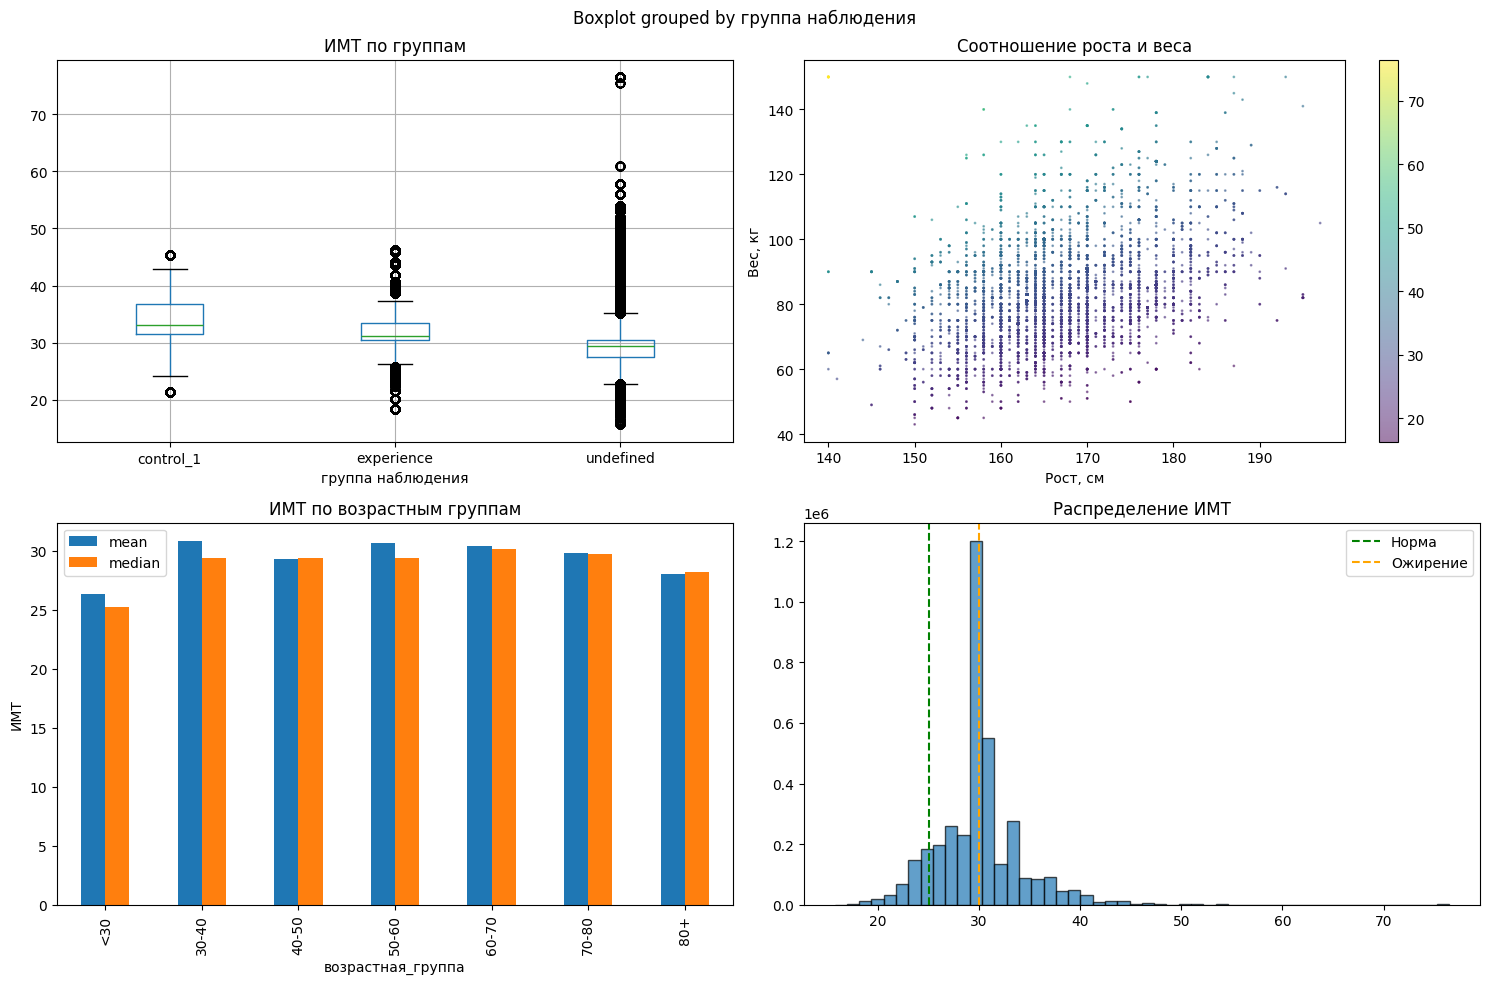

<Figure size 640x480 with 0 Axes>

34724

In [65]:
# Загружаем данные
df = pd.read_csv('data/clean_primary_dedup.csv', parse_dates=['время измерения'])
print(f"Загружено измерений: {len(df):,}")
print(f"Уникальных пациентов: {df['id пациента'].nunique():,}")

# Создаем возрастные группы
df['возраст_полных_лет'] = df['возраст'].round().astype('Int64')
bins = [0, 30, 40, 50, 60, 70, 80, 120]
labels = ['<30', '30-40', '40-50', '50-60', '60-70', '70-80', '80+']
df['возрастная_группа'] = pd.cut(df['возраст_полных_лет'], bins=bins, labels=labels)

print(f"\nПропуски до импутации:")
print(f"  Рост: {df['рост'].isna().sum():,} ({df['рост'].isna().mean()*100:.1f}%)")
print(f"  Вес: {df['масса'].isna().sum():,} ({df['масса'].isna().mean()*100:.1f}%)")
print(f"  Основное заболевание: {df['основное заболевание'].isna().sum():,}")
print(f"  Сопутствующие: {df['сопутствующие заболевание'].isna().sum():,}")

# Импутация роста и веса (медиана по группе + возраст)
df_imputed = df.copy()
for group in df_imputed['группа наблюдения'].unique():
    for age_group in labels:
        mask = (df_imputed['группа наблюдения'] == group) & (df_imputed['возрастная_группа'] == age_group)
        h_med = df_imputed.loc[mask, 'рост'].median()
        w_med = df_imputed.loc[mask, 'масса'].median()
        if pd.notna(h_med):
            df_imputed.loc[mask & df_imputed['рост'].isna(), 'рост'] = h_med
        if pd.notna(w_med):
            df_imputed.loc[mask & df_imputed['масса'].isna(), 'масса'] = w_med

# Глобальные медианы для оставшихся
df_imputed['рост'].fillna(df_imputed['рост'].median(), inplace=True)
df_imputed['масса'].fillna(df_imputed['масса'].median(), inplace=True)

# Импутация заболеваний
df_imputed['основное заболевание'].fillna('Не указано', inplace=True)
df_imputed['сопутствующие заболевание'].fillna('Нет данных', inplace=True)

# Создание новых признаков
df_imputed['ИМТ'] = (df_imputed['масса'] / ((df_imputed['рост']/100)**2)).round(1)
df_imputed['пульсовое_давление'] = df_imputed['САД'] - df_imputed['ДАД']

print(f"\nПосле импутации:")
print(f"  Пропусков: {df_imputed.isnull().sum().sum()}")
print(f"  Средний ИМТ: {df_imputed['ИМТ'].mean():.1f}")
print(f"  Медиана ИМТ: {df_imputed['ИМТ'].median():.1f}")

df_imputed.to_csv('data/primary_imputed.csv', index=False)

#КОРРЕКЦИЯ И ВЕРИФИКАЦИЯ ИМТ
# Ограничиваем физиологические пределы
df_corrected = df_imputed.copy()
df_corrected.loc[df_corrected['масса'] > 150, 'масса'] = 150
df_corrected.loc[df_corrected['масса'] < 40, 'масса'] = 40
df_corrected.loc[df_corrected['рост'] > 210, 'рост'] = 210
df_corrected.loc[df_corrected['рост'] < 140, 'рост'] = 140
df_corrected['ИМТ'] = (df_corrected['масса'] / ((df_corrected['рост']/100)**2)).round(1)

print(f"\nСравнение ИМТ до/после коррекции:")
print(f"  До - среднее: {df_imputed['ИМТ'].mean():.1f}, макс: {df_imputed['ИМТ'].max():.1f}")
print(f"  После - среднее: {df_corrected['ИМТ'].mean():.1f}, макс: {df_corrected['ИМТ'].max():.1f}")

# Поиск аномалий
high_bmi = df_corrected[df_corrected['ИМТ'] > 50]['id пациента'].nunique()
print(f"\nПациентов с ИМТ > 50: {high_bmi}")

# Распределение по категориям
bmi_bins = [0, 18.5, 25, 30, 35, 40, 100]
bmi_labels = ['Недостаточный', 'Норма', 'Избыточный', 'Ожирение 1', 'Ожирение 2', 'Ожирение 3']
df_corrected['ИМТ_категория'] = pd.cut(df_corrected['ИМТ'], bins=bmi_bins, labels=bmi_labels)
print("\nРаспределение по категориям ИМТ:")
print(df_corrected['ИМТ_категория'].value_counts())

# Визуализация
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Boxplot по группам
df_corrected.boxplot(column='ИМТ', by='группа наблюдения', ax=axes[0,0])
axes[0,0].set_title('ИМТ по группам')

# Scatter рост-вес
sample = df_corrected.sample(10000)
scatter = axes[0,1].scatter(sample['рост'], sample['масса'], c=sample['ИМТ'], cmap='viridis', alpha=0.5, s=1)
axes[0,1].set_xlabel('Рост, см')
axes[0,1].set_ylabel('Вес, кг')
axes[0,1].set_title('Соотношение роста и веса')
plt.colorbar(scatter, ax=axes[0,1])

# ИМТ по возрастам
bmi_by_age = df_corrected.groupby('возрастная_группа')['ИМТ'].agg(['mean', 'median'])
bmi_by_age.plot(kind='bar', ax=axes[1,0])
axes[1,0].set_title('ИМТ по возрастным группам')
axes[1,0].set_ylabel('ИМТ')

# Гистограмма ИМТ
axes[1,1].hist(df_corrected['ИМТ'], bins=50, edgecolor='black', alpha=0.7)
axes[1,1].axvline(x=25, color='green', ls='--', label='Норма')
axes[1,1].axvline(x=30, color='orange', ls='--', label='Ожирение')
axes[1,1].set_title('Распределение ИМТ')
axes[1,1].legend()

plt.tight_layout()
plt.savefig('data/photo/bmi_analysis.png', dpi=150)
plt.show()
df_corrected.to_csv('data/primary_imputed_corrected.csv', index=False)
# Очистка памяти от промежуточных данных
del df_imputed 
del df  
del sample  
plt.tight_layout()
plt.savefig('data/photo/bmi_analysis.png', dpi=150)
plt.show()
plt.close() 
plt.close('all')  
import gc
gc.collect()

## ЭТАП 14: ФИНАЛЬНЫЕ ИСПРАВЛЕНИЯ И ЦЕЛЕВАЯ ПЕРЕМЕННАЯ

In [66]:
# Детальный анализ группы 30-40 лет
group_30_40 = df_corrected[(df_corrected['возраст'] >= 30) & (df_corrected['возраст'] < 40)]
print("\nГруппа 30-40 лет по категориям:")
for group in group_30_40['группа наблюдения'].unique():
    g_data = group_30_40[group_30_40['группа наблюдения'] == group]
    print(f"\n{group}:")
    print(f"  Пациентов: {g_data['id пациента'].nunique()}")
    print(f"  Средний вес: {g_data['масса'].mean():.1f} кг")
    print(f"  Средний ИМТ: {g_data['ИМТ'].mean():.1f}")

# Корреляции по группам
print("\nКорреляция ИМТ-САД по группам:")
for group in df_corrected['группа наблюдения'].unique():
    g_data = df_corrected[df_corrected['группа наблюдения'] == group]
    corr = g_data['ИМТ'].corr(g_data['САД'])
    print(f"  {group}: {corr:.3f}")

# Выявление выбросов
outliers = set()
outliers.update(df_corrected[df_corrected['ИМТ'] > 50]['id пациента'].unique())
outliers.update(df_corrected[(df_corrected['масса'] > 150) & (df_corrected['рост'] < 150)]['id пациента'].unique())
print(f"\nВсего пациентов-выбросов: {len(outliers)} ({len(outliers)/df_corrected['id пациента'].nunique()*100:.2f}%)")

# Баланс классов ИМТ
print("\nБаланс классов ИМТ:")
class_dist = df_corrected['ИМТ_категория'].value_counts()
for cat, count in class_dist.items():
    print(f"  {cat}: {count:,} ({count/len(df_corrected)*100:.1f}%)")
outliers.clear()
del outliers
gc.collect()


Группа 30-40 лет по категориям:

undefined:
  Пациентов: 418
  Средний вес: 85.1 кг
  Средний ИМТ: 29.2

experience:
  Пациентов: 43
  Средний вес: 123.7 кг
  Средний ИМТ: 39.0

control_1:
  Пациентов: 16
  Средний вес: 106.0 кг
  Средний ИМТ: 34.2

Корреляция ИМТ-САД по группам:
  experience: -0.024
  undefined: 0.065
  control_1: 0.026

Всего пациентов-выбросов: 23 (0.23%)

Баланс классов ИМТ:
  Избыточный: 1,546,348 (41.1%)
  Ожирение 1: 1,473,391 (39.1%)
  Норма: 370,821 (9.9%)
  Ожирение 2: 277,563 (7.4%)
  Ожирение 3: 89,668 (2.4%)
  Недостаточный: 6,013 (0.2%)


0

In [67]:
# Исключение выбросов
outlier_patients = set()
outlier_patients.update(df_corrected[df_corrected['ИМТ'] > 50]['id пациента'].unique())

few_measurements = df_corrected.groupby('id пациента').size()
outlier_patients.update(few_measurements[few_measurements < 5].index)

print(f"Исключено пациентов: {len(outlier_patients)}")
df_clean = df_corrected[~df_corrected['id пациента'].isin(outlier_patients)].copy()
print(f"Осталось пациентов: {df_clean['id пациента'].nunique()}")
print(f"Измерений: {len(df_clean):,}")
del df_corrected
del few_measurements
# Агрегация признаков
def iqr(x): return x.quantile(0.75) - x.quantile(0.25)
def days_diff(x): return (x.max() - x.min()).days

ml_features = df_clean.groupby('id пациента').agg({
    'возраст': 'first', 'рост': 'first', 'масса': 'first', 'ИМТ': 'first',
    'часовой пояс': 'first', 'группа наблюдения': 'first',
    'САД': ['mean', 'std', 'min', 'max', 'median', iqr],
    'ДАД': ['mean', 'std', 'min', 'max', 'median'],
    'ЧП': ['mean', 'std', 'min', 'max', 'median'],
    'пульсовое_давление': ['mean', 'std'],
    'время измерения': ['count', days_diff]
}).round(1)

ml_features.columns = [f"{col[0]}_{col[1]}" if col[1] not in ['first', 'count'] 
                       else f"{col[0]}" for col in ml_features.columns]
ml_features = ml_features.reset_index().rename(columns={'id пациента': 'patient_id'})
del df_clean
# Добавление КЗС
kzs = pd.read_csv('data/kzs.csv')
kzs_per_patient = kzs.groupby('id пациента').size().reset_index(name='kzs_count')
ml_features = ml_features.merge(kzs_per_patient, left_on='patient_id', right_on='id пациента', how='left')
ml_features['kzs_count'].fillna(0, inplace=True)
ml_features.drop('id пациента', axis=1, inplace=True)
del kzs
del kzs_per_patient
print(f"\nФинальный ML датасет: {ml_features.shape[0]} пациентов, {ml_features.shape[1]} признаков")
ml_features.to_csv('data/ml_dataset_final.csv', index=False)
del ml_features
gc.collect()


Исключено пациентов: 361
Осталось пациентов: 9642
Измерений: 3,753,446

Финальный ML датасет: 9642 пациентов, 28 признаков


0

In [68]:
ml_df = pd.read_csv('data/ml_dataset_final.csv')

# Исправление пропусков в возрасте
missing_age = ml_df['возраст'].isna().sum()
if missing_age > 0:
    median_age = ml_df.groupby('группа наблюдения')['возраст'].median()
    for group, med in median_age.items():
        ml_df.loc[(ml_df['группа наблюдения'] == group) & (ml_df['возраст'].isna()), 'возраст'] = med
    print(f"Заполнено пропусков в возрасте: {missing_age}")
    del median_age  # удаляем после использования

# Проверка группы experience 30-40 лет
high_bmi_exp = ml_df[(ml_df['группа наблюдения'] == 'experience') & 
                     (ml_df['ИМТ'] > 35) & 
                     (ml_df['возраст'].between(30, 40))]
print(f"\nПациентов experience 30-40 лет с ИМТ>35: {len(high_bmi_exp)}")
del high_bmi_exp  # удаляем временную выборку

# Финальная статистика (просто печатаем, переменные не создаем)
print(f"\nФинальная статистика:")
print(f"  Пациентов: {len(ml_df)}")
print(f"  Признаков: {len(ml_df.columns)}")
print(f"  Диапазон ИМТ: {ml_df['ИМТ'].min():.1f} - {ml_df['ИМТ'].max():.1f}")
print(f"  Диапазон возраста: {ml_df['возраст'].min():.1f} - {ml_df['возраст'].max():.1f}")
print(f"  Диапазон САД: {ml_df['САД_mean'].min():.1f} - {ml_df['САД_mean'].max():.1f}")

# Создание целевых переменных
median_kzs = ml_df['kzs_count'].median()
ml_df['target_high_risk'] = (ml_df['kzs_count'] > median_kzs).astype(int)
del median_kzs  # удаляем после использования

bins = [0, 50, 100, 200, 1000]
labels = ['Низкий', 'Средний', 'Высокий', 'Очень высокий']
ml_df['target_risk_category'] = pd.cut(ml_df['kzs_count'], bins=bins, labels=labels)

print(f"\nЦелевые переменные:")
print(f"  Бинарная: 0={sum(ml_df['target_high_risk']==0)}, 1={sum(ml_df['target_high_risk']==1)}")
print(f"  Мультикласс:\n{ml_df['target_risk_category'].value_counts()}")
print(f"  Регрессия: {ml_df['kzs_count'].min()} - {ml_df['kzs_count'].max()}, среднее={ml_df['kzs_count'].mean():.1f}")

# Сохранение
ml_df.to_csv('data/ml_dataset_ready.csv', index=False)
del therapy
del ml_df
gc.collect()

Заполнено пропусков в возрасте: 3

Пациентов experience 30-40 лет с ИМТ>35: 39

Финальная статистика:
  Пациентов: 9642
  Признаков: 28
  Диапазон ИМТ: 15.7 - 50.0
  Диапазон возраста: 18.2 - 100.9
  Диапазон САД: 80.3 - 207.2

Целевые переменные:
  Бинарная: 0=4833, 1=4809
  Мультикласс:
target_risk_category
Низкий           2909
Высокий          2470
Средний          2260
Очень высокий    1946
Name: count, dtype: int64
  Регрессия: 0.0 - 881.0, среднее=123.4


0

In [70]:
import os

files_to_delete = [
    'data/primary_clean.csv',
    'data/primary_imputed.csv',
    'data/primary_imputed_corrected.csv',
    'data/ml_dataset_final.csv',
    'data/patient_program.csv',
    'data/kzs.csv',
    'data/clean_primary_dedup.csv', 
    'data/therapy.csv'
]

for file in files_to_delete:
    if os.path.exists(file):
        os.remove(file)
        print(f"Удален: {file}")
    else:
        print(f"Не найден: {file}")

Не найден: data/primary_clean.csv
Не найден: data/primary_imputed.csv
Не найден: data/primary_imputed_corrected.csv
Не найден: data/ml_dataset_final.csv
Не найден: data/patient_program.csv
Не найден: data/kzs.csv
Удален: data/clean_primary_dedup.csv
Не найден: data/therapy.csv
